# Bank Marketing Case Study — AnalystLab Africa Week 5

## Step 1: Business Problem Statement

Banks run marketing campaigns to encourage customers to subscribe to term deposits, 
but not all customers respond positively. Understanding which customer characteristics 
and campaign approaches are associated with subscription can help the bank target future 
campaigns more effectively improving conversion rates while reducing wasted contact effort.

**Business Question:** Which customer groups are more likely to subscribe to a term 
deposit, and which factors influence this decision?

## Step 2: Data Exploration & Analysis
### 2.1 Dataset Overview

In [1]:
import pandas as pd

df = pd.read_csv("bank.csv")

print("Shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape (rows, columns): (11162, 17)

First 5 rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [2]:
print("Data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Data types:
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
deposit        str
dtype: object

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Number of duplicate rows: 0


### 2.2 Data Cleaning

The dataset has no missing values (NaN) or duplicate rows. However, some columns use 
`"unknown"` as a placeholder for missing information, and `pdays` uses `-1` to indicate 
a customer was never previously contacted. These are treated as data quality issues 
and handled below.

In [3]:
# Check how many "unknown" values exist in each categorical column
cols_to_check = ['job', 'education', 'contact', 'poutcome']

for col in cols_to_check:
    count = (df[col] == 'unknown').sum()
    pct = round(count / len(df) * 100, 1)
    print(f"{col}: {count} unknown values ({pct}%)")

job: 70 unknown values (0.6%)
education: 497 unknown values (4.5%)
contact: 2346 unknown values (21.0%)
poutcome: 8326 unknown values (74.6%)


In [4]:
# pdays = -1 means the customer was never contacted in a previous campaign
# Create a clearer flag column instead of using -1 as a number
df['was_previously_contacted'] = df['pdays'] != -1

print(df['was_previously_contacted'].value_counts())
print("\nSample of pdays vs new flag column:")
print(df[['pdays', 'was_previously_contacted']].head(10))

was_previously_contacted
False    8324
True     2838
Name: count, dtype: int64

Sample of pdays vs new flag column:
   pdays  was_previously_contacted
0     -1                     False
1     -1                     False
2     -1                     False
3     -1                     False
4     -1                     False
5     -1                     False
6     -1                     False
7     -1                     False
8     -1                     False
9     -1                     False


**Cleaning summary:** No missing values or duplicate rows were found. `"unknown"` 
categorical values were retained as a valid category rather than dropped, since removing 
them would discard up to 74.6% of rows in some columns. A new `was_previously_contacted` 
flag column was created from `pdays` to avoid `-1` placeholders distorting numeric analysis. 
The cleaned dataset is exported below.

In [5]:
df.to_csv("bank_cleaned.csv", index=False)
print("Saved bank_cleaned.csv with shape:", df.shape)

Saved bank_cleaned.csv with shape: (11162, 18)


### 2.3 Summary Statistics

Before jumping into charts, let's take a quick look at the numbers behind each 
numeric column things like average balance, typical age range, and how many 
times customers were contacted. This gives us a sense of what's "normal" in the 
data before we start visualizing it, and helps us spot anything unusual (like 
outliers) early on.

In [6]:
print("Summary statistics (numeric columns):")
print(df.describe().round(1))

Summary statistics (numeric columns):
           age  balance      day  duration  campaign    pdays  previous
count  11162.0  11162.0  11162.0   11162.0   11162.0  11162.0   11162.0
mean      41.2   1528.5     15.7     372.0       2.5     51.3       0.8
std       11.9   3225.4      8.4     347.1       2.7    108.8       2.3
min       18.0  -6847.0      1.0       2.0       1.0     -1.0       0.0
25%       32.0    122.0      8.0     138.0       1.0     -1.0       0.0
50%       39.0    550.0     15.0     255.0       2.0     -1.0       0.0
75%       49.0   1708.0     22.0     496.0       3.0     20.8       1.0
max       95.0  81204.0     31.0    3881.0      63.0    854.0      58.0


**Key observations from summary statistics:**
- `balance` and `duration` are both right-skewed a small number of high-value 
  balances/long calls pull the average above the median.
- `campaign` shows some customers contacted up to 63 times, suggesting possible 
  over-contacting/diminishing returns worth investigating.
- Most customers had no previous campaign contact (`pdays`/`previous` mostly at 
  placeholder/zero values), consistent with earlier findings.

### 2.4 Distributions & Visualizations

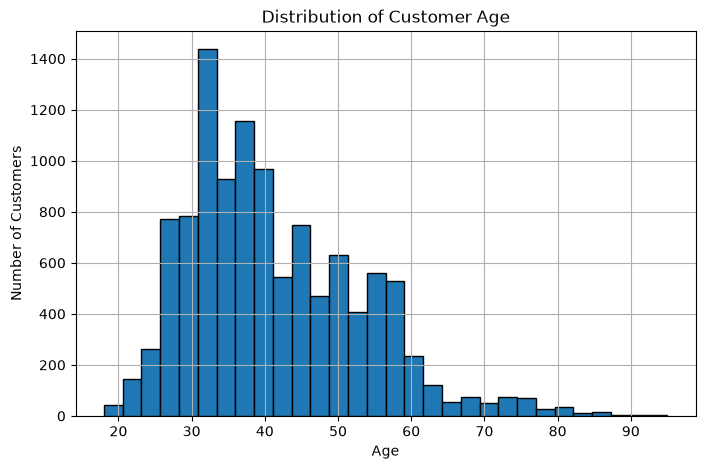

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['age'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\KOGBARA BURABARI\AppData\Local\Temp\ipykernel_9612\2012686627.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['balance'], vert=False)


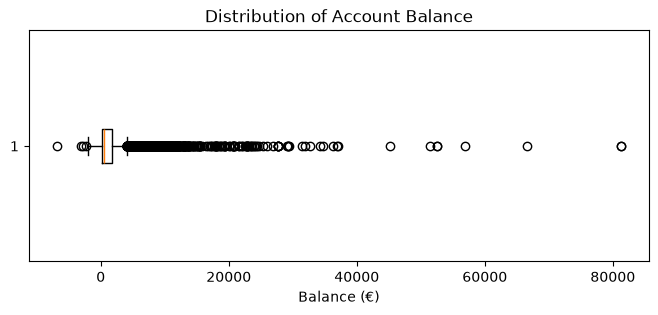

In [10]:
plt.figure(figsize=(8,3))
plt.boxplot(df['balance'], vert=False)
plt.title('Distribution of Account Balance')
plt.xlabel('Balance (€)')
plt.show()

**Observations:**
- Customer age is right skewed, concentrated between 30–40 years old, with fewer 
  older customers.
- Account balance is heavily right-skewed most customers hold modest balances 
  (median ≈ €550), while a small number of high balance outliers pull the average 
  up to €1,528. Median is more representative of a "typical" customer.

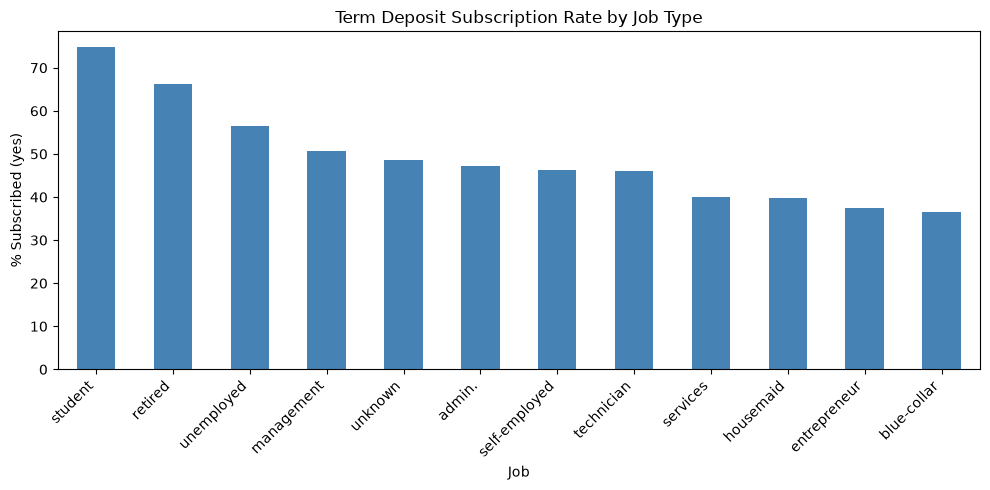

In [11]:
import matplotlib.pyplot as plt

deposit_by_job = df.groupby('job')['deposit'].value_counts(normalize=True).unstack() * 100

deposit_by_job['yes'].sort_values(ascending=False).plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title('Term Deposit Subscription Rate by Job Type')
plt.xlabel('Job')
plt.ylabel('% Subscribed (yes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding: Job type strongly influences subscription rate.** Students (~75%) and 
retirees (~65%) are far more likely to subscribe to a term deposit than working 
professionals such as blue-collar workers or entrepreneurs (~36-38%). This suggests 
the bank's marketing campaigns may be more effective when targeted toward students 
and retirees.

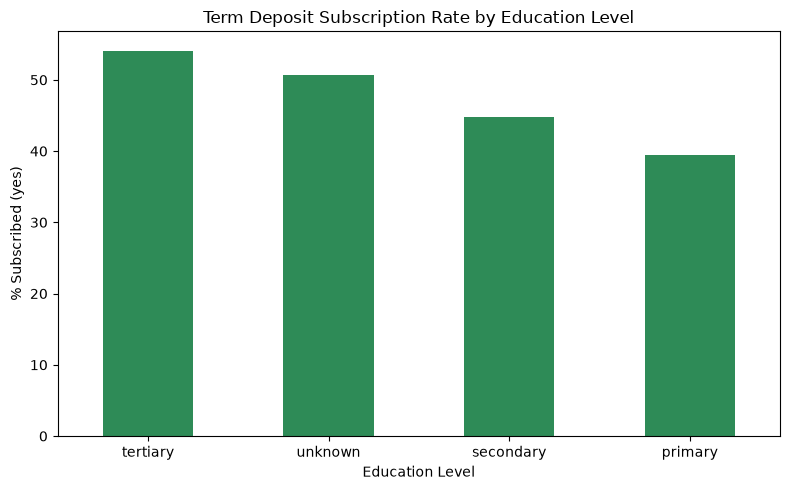

In [12]:
deposit_by_edu = df.groupby('education')['deposit'].value_counts(normalize=True).unstack() * 100

deposit_by_edu['yes'].sort_values(ascending=False).plot(kind='bar', figsize=(8,5), color='seagreen')
plt.title('Term Deposit Subscription Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('% Subscribed (yes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding: Education level has a moderate positive relationship with subscription.** 
Customers with tertiary education subscribe at ~54%, compared to ~38% for those 
with only primary education suggesting more educated customers may be more 
receptive to term deposit products.

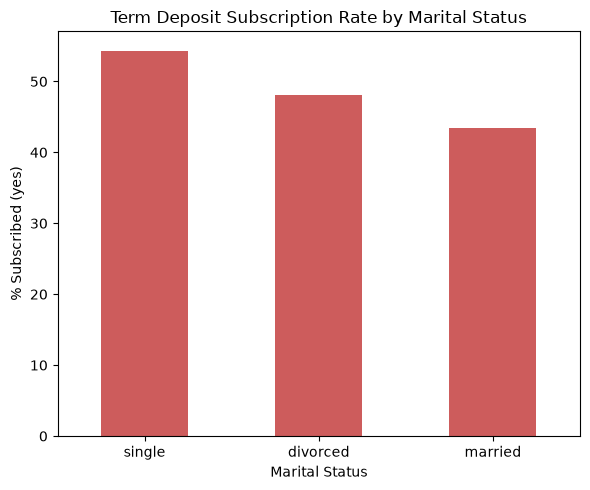

In [13]:
deposit_by_marital = df.groupby('marital')['deposit'].value_counts(normalize=True).unstack() * 100

deposit_by_marital['yes'].sort_values(ascending=False).plot(kind='bar', figsize=(6,5), color='indianred')
plt.title('Term Deposit Subscription Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('% Subscribed (yes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding: Single customers subscribe at a higher rate (~54%) than married 
customers (~44%).** This is consistent with the job-type pattern customers 
with fewer financial commitments (students, singles) appear more open to 
subscribing to term deposits.

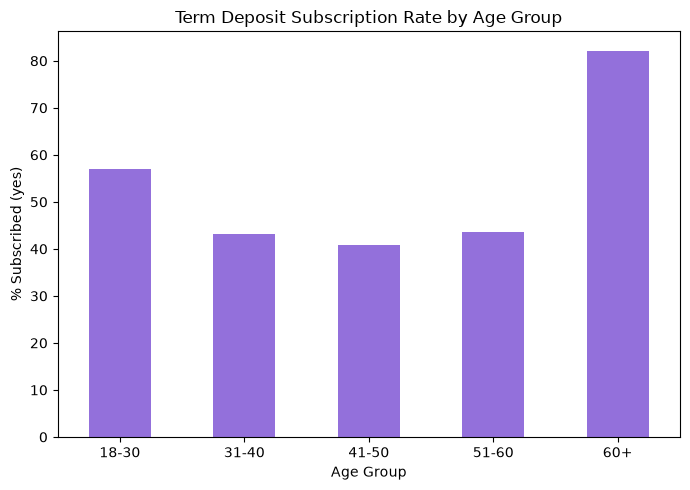

In [14]:
# Group age into bins for easier comparison
df['age_group'] = pd.cut(df['age'], bins=[18,30,40,50,60,100], 
                          labels=['18-30','31-40','41-50','51-60','60+'])

deposit_by_age = df.groupby('age_group', observed=True)['deposit'].value_counts(normalize=True).unstack() * 100

deposit_by_age['yes'].plot(kind='bar', figsize=(7,5), color='mediumpurple')
plt.title('Term Deposit Subscription Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('% Subscribed (yes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding: Age has a strong U-shaped relationship with subscription (a key driver).** 
Subscription rates are highest for customers aged 60+ (~82%) and 18-30 (~57%), but 
dip to their lowest for customers aged 31-50 (~41-43%) the prime working/family 
years. This mirrors the job-type finding: customers with fewer financial commitments 
(young or retired) are far more likely to subscribe than working-age adults.

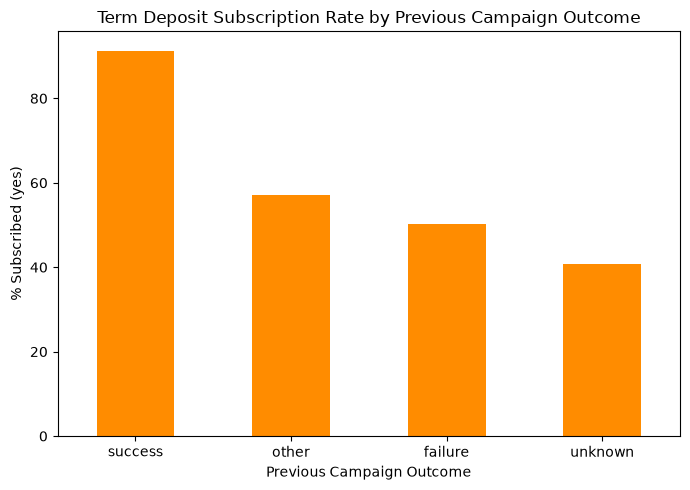

In [15]:
deposit_by_poutcome = df.groupby('poutcome')['deposit'].value_counts(normalize=True).unstack() * 100
deposit_by_poutcome['yes'].sort_values(ascending=False).plot(kind='bar', figsize=(7,5), color='darkorange')
plt.title('Term Deposit Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('% Subscribed (yes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding: Previous campaign outcome is the single strongest driver of subscription 
found so far.** Customers who succeeded in a previous campaign subscribe again at 
~91%, compared to ~41% for customers never previously contacted. This suggests the 
bank should prioritize re-engaging past successful customers, as they convert at 
nearly double the overall average rate (~47%).

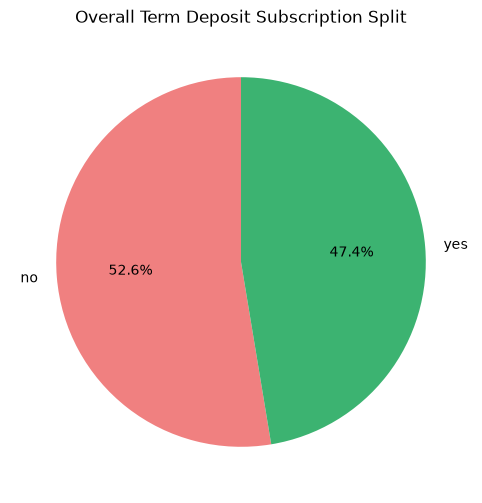

In [16]:
deposit_counts = df['deposit'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(deposit_counts, labels=deposit_counts.index, autopct='%1.1f%%', 
        colors=['lightcoral','mediumseagreen'], startangle=90)
plt.title('Overall Term Deposit Subscription Split')
plt.show()

**Overview:** Of the 11,162 customers contacted, 47.4% subscribed to a term deposit 
while 52.6% did not a fairly balanced outcome, meaning neither class dominates 
the dataset.

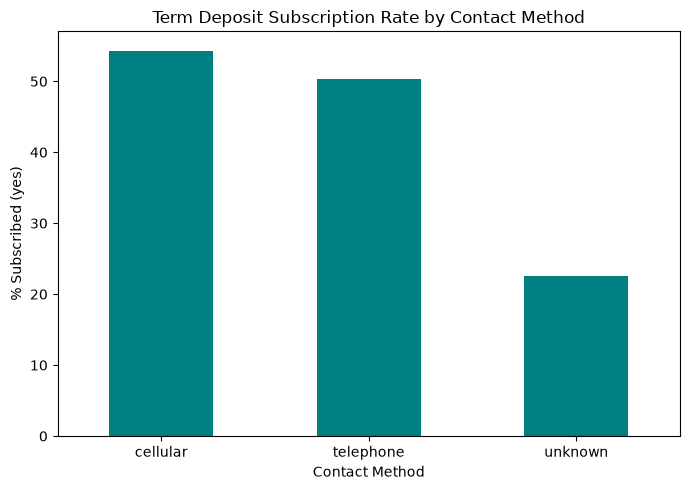

In [17]:
deposit_by_contact = df.groupby('contact')['deposit'].value_counts(normalize=True).unstack() * 100

deposit_by_contact['yes'].sort_values(ascending=False).plot(kind='bar', figsize=(7,5), color='teal')
plt.title('Term Deposit Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('% Subscribed (yes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding: Contact method matters.** Cellular (~54%) and telephone (~50%) contact 
methods convert similarly well, but customers with an "unknown" contact method 
convert far worse (~23%) despite representing 21% of all customers contacted. 
This suggests the bank should prioritize direct phone-based contact channels.

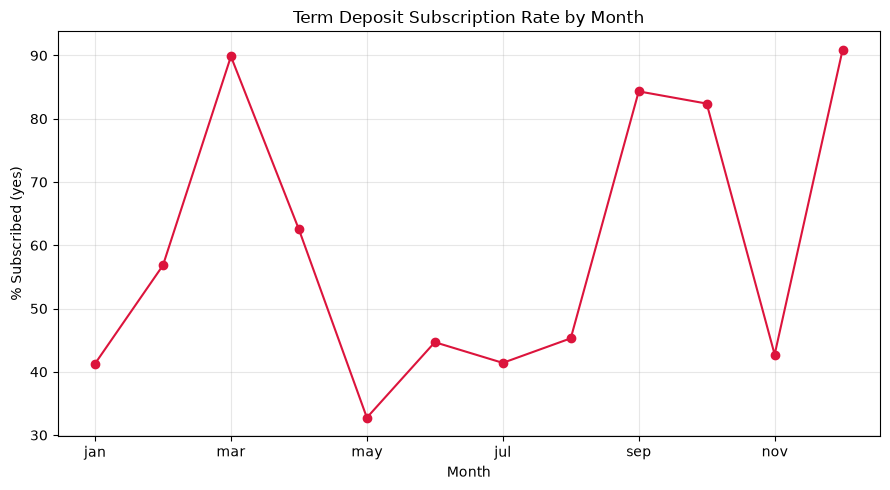

In [18]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

deposit_by_month = df.groupby('month', observed=True)['deposit'].value_counts(normalize=True).unstack() * 100

deposit_by_month['yes'].plot(kind='line', marker='o', figsize=(9,5), color='crimson')
plt.title('Term Deposit Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('% Subscribed (yes)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
print("Number of contacts per month:")
print(df['month'].value_counts().sort_index())

Number of contacts per month:
month
jan     344
feb     776
mar     276
apr     923
may    2824
jun    1222
jul    1514
aug    1519
sep     319
oct     392
nov     943
dec     110
Name: count, dtype: int64


**Finding: Subscription rate varies by month, but low-volume months should be 
interpreted cautiously.** May had the highest contact volume (2,824 contacts, 25% 
of the dataset) but the lowest subscription rate (~33%) suggesting the bank's 
largest campaign push targeted a less receptive period, or oversaturated May with 
contacts. Conversely, apparent "spikes" in March, September, and December (~84-90%) 
are based on much smaller sample sizes (110-319 contacts) and should not be 
over-interpreted as strong seasonal effects without further data.

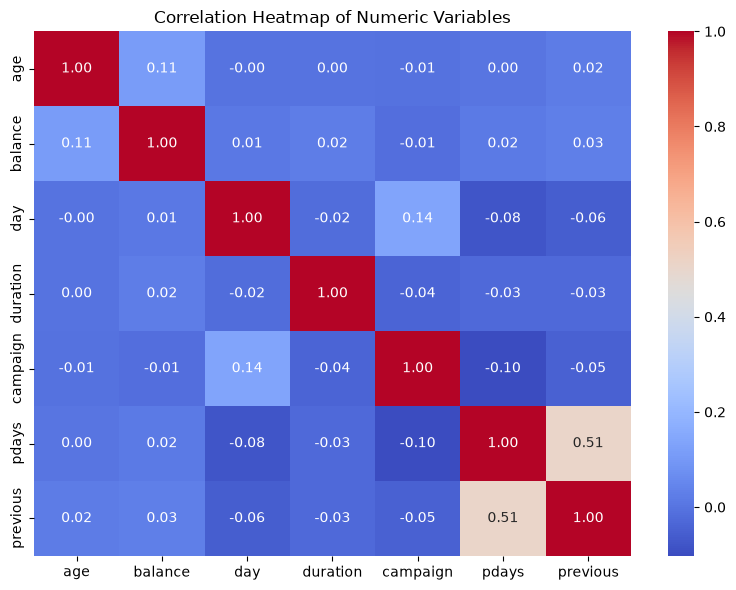

In [20]:
import seaborn as sns

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

**Correlation heatmap:** Numeric variables show mostly weak correlations with each 
other, indicating limited redundancy between features. The only notable relationship 
is between `pdays` and `previous` (0.51), which is expected since both relate to 
prior contact history.

<Figure size 800x500 with 0 Axes>

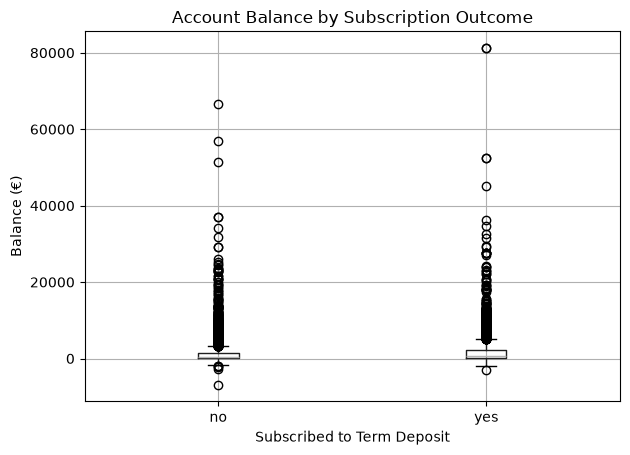

In [21]:
plt.figure(figsize=(8,5))
df.boxplot(column='balance', by='deposit')
plt.title('Account Balance by Subscription Outcome')
plt.suptitle('')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Balance (€)')
plt.tight_layout()
plt.show()

In [22]:
print("Median balance by subscription outcome:")
print(df.groupby('deposit')['balance'].median())

print("\nMean balance by subscription outcome:")
print(df.groupby('deposit')['balance'].mean())

Median balance by subscription outcome:
deposit
no     414.0
yes    733.0
Name: balance, dtype: float64

Mean balance by subscription outcome:
deposit
no     1280.227141
yes    1804.267915
Name: balance, dtype: float64


**Finding: Higher account balance is associated with subscription.** Subscribers 
have a median balance of €733 vs €414 for non-subscribers nearly double. This 
pattern holds for both median and mean, making it a reliable signal that 
higher-balance customers are more receptive to term deposit offers.

## Step 3: Identify Key Drivers

Based on the exploratory analysis above, the following factors show the strongest 
relationship with term deposit subscription, ranked from strongest to weakest:

1. **Previous campaign outcome** — success (~91%) vs never contacted (~41%)
2. **Age** — 60+ (~82%) and 18-30 (~57%) vs 31-50 (~41-43%)
3. **Job type** — students (~75%) and retirees (~65%) vs blue-collar/entrepreneurs (~36-38%)
4. **Contact method** — cellular/telephone (~50-54%) vs unknown (~23%)
5. **Marital status** — single (~54%) vs married (~44%)
6. **Account balance** — subscribers hold nearly double the median balance of non-subscribers
7. **Education level** — tertiary (~54%) vs primary (~38%)

Duration and campaign month were also explored, but duration is excluded as a 
targeting driver (it's only known after a call happens, not before), and month 
patterns need cautious interpretation due to uneven contact volume across months.

## Step 5: Recommendations

1. **Prioritize re-engaging customers with previous campaign success.** They convert 
   at ~91%, nearly double the overall rate this is the single highest-ROI segment 
   to target first in future campaigns.

2. **Shift marketing focus toward students, retirees, and single customers.** These 
   groups consistently show the highest subscription rates across age, job, and 
   marital status campaigns tailored to their life stage (e.g. flexible savings 
   messaging) may perform better than generic outreach.

3. **Reduce reliance on "unknown" contact methods.** Since cellular and telephone 
   contact convert roughly twice as well, the bank should investigate why 21% of 
   contacts have no recorded method and shift toward direct phone contact where possible.

4. **Reconsider campaign timing and volume, especially around May.** The month with 
   the highest contact volume had the lowest conversion rate, suggesting the bank 
   may be overextending contact efforts during a less receptive period spreading 
   volume more evenly, or reviewing what changed operationally in May, could improve efficiency.

5. **Use account balance as a pre-screening signal.** Customers with higher balances 
   convert at nearly double the rate of lower-balance customers incorporating 
   balance into targeting criteria could improve campaign efficiency without 
   needing new data collection.